<a href="https://colab.research.google.com/github/Adithyaanil121/report/blob/main/ml_report(4)_26_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import time
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 1. Load MNIST dataset
# ============================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)





11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
# ============================================================
# 2. Preprocess the data
# ============================================================

# Convert pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("x_train range:", x_train.min(), "→", x_train.max())
print("x_test range:", x_test.min(), "→", x_test.max())



x_train range: 0.0 → 1.0
x_test range: 0.0 → 1.0


In [4]:
# ============================================================
# 3. Activation functions to compare
# ============================================================

activations = ["relu", "sigmoid", "tanh"]



In [5]:
# ============================================================
# 4. Model creation function
# ============================================================

def create_model(activation_function):
    model = tf.keras.Sequential([
        # Input layer
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # Hidden layers
        tf.keras.layers.Dense(128, activation=activation_function),
        tf.keras.layers.Dense(64, activation=activation_function),

        # Output layer
        # 10 neurons because MNIST has digits 0 to 9
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model factory ready. Activations to test:", activations)



Model factory ready. Activations to test: ['relu', 'sigmoid', 'tanh']


In [6]:
# ============================================================
# 5. Train models for each activation function
# ============================================================

results = {}

for activation in activations:
    print("\n" + "=" * 50)
    print("Activation Function:", activation)
    print("=" * 50)

    # Create model
    model = create_model(activation)

    # Record starting time
    start_time = time.time()

    # Train model
    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    # Calculate training time
    training_time = time.time() - start_time

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    # Store results
    results[activation] = {
        "time": training_time,
        "accuracy": test_accuracy,
        "loss": test_loss,
        "history": history
    }

    print("\nTraining Time:", round(training_time, 2), "seconds")
    print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
    print("Test Loss:", round(test_loss, 4))



Activation Function: relu


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8997 - loss: 0.3602 - val_accuracy: 0.9567 - val_loss: 0.1569
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9559 - loss: 0.1497 - val_accuracy: 0.9718 - val_loss: 0.1085
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9683 - loss: 0.1054 - val_accuracy: 0.9693 - val_loss: 0.1029
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0782 - val_accuracy: 0.9738 - val_loss: 0.0928
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9813 - loss: 0.0616 - val_accuracy: 0.9770 - val_loss: 0.0858
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9844 - loss: 0.0499 - val_accuracy: 0.9742 - val_loss: 0.0846
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9874 - loss: 0.0405 - val_accuracy: 0.9807 - val_loss: 0.0750
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9904 - loss: 0.0328 - val_accuracy: 0.

In [7]:
# ============================================================
# 6. Display comparison
# ============================================================

print("\n\n========== FINAL COMPARISON ==========")
print("\nActivation\tTraining Time\tAccuracy")
print("-" * 45)

for activation in activations:
    print(
        activation,
        "\t\t",
        round(results[activation]["time"], 2),
        "sec\t",
        round(results[activation]["accuracy"] * 100, 2),
        "%"
    )





========== FINAL COMPARISON ==========

Activation	Training Time	Accuracy
---------------------------------------------
relu 		 25.86 sec	 97.53 %
sigmoid 		 27.45 sec	 97.13 %
tanh 		 27.93 sec	 97.54 %


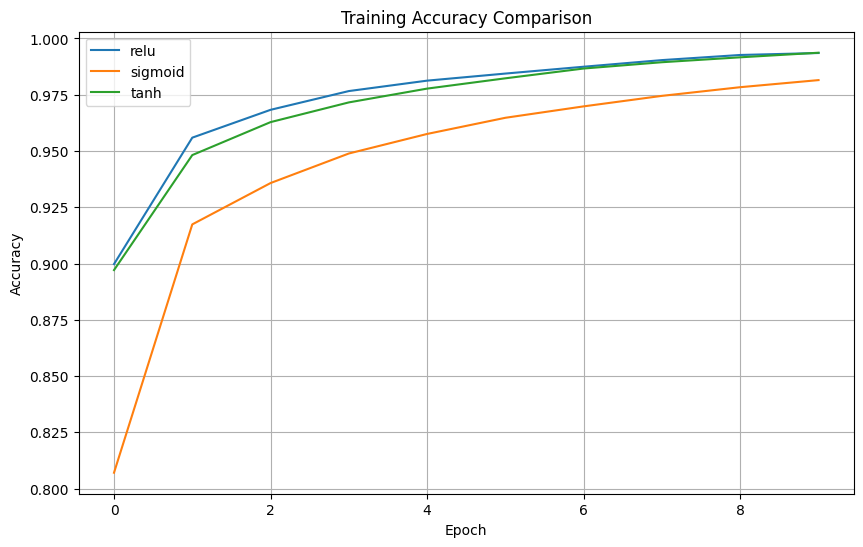

In [8]:
# ============================================================
# 7. Plot training accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for activation in activations:
    history = results[activation]["history"]
    plt.plot(
        history.history["accuracy"],
        label=activation
    )

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()



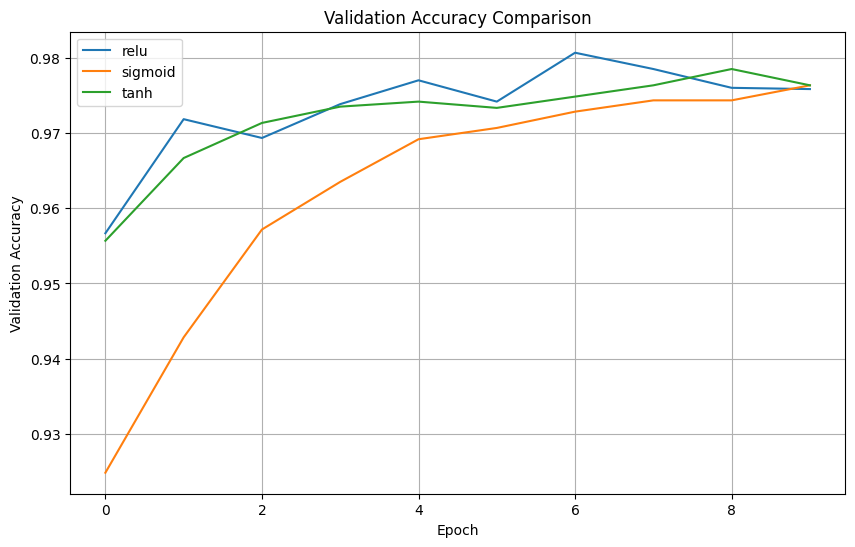

In [9]:
# ============================================================
# 8. Plot validation accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for activation in activations:
    history = results[activation]["history"]
    plt.plot(
        history.history["val_accuracy"],
        label=activation
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()



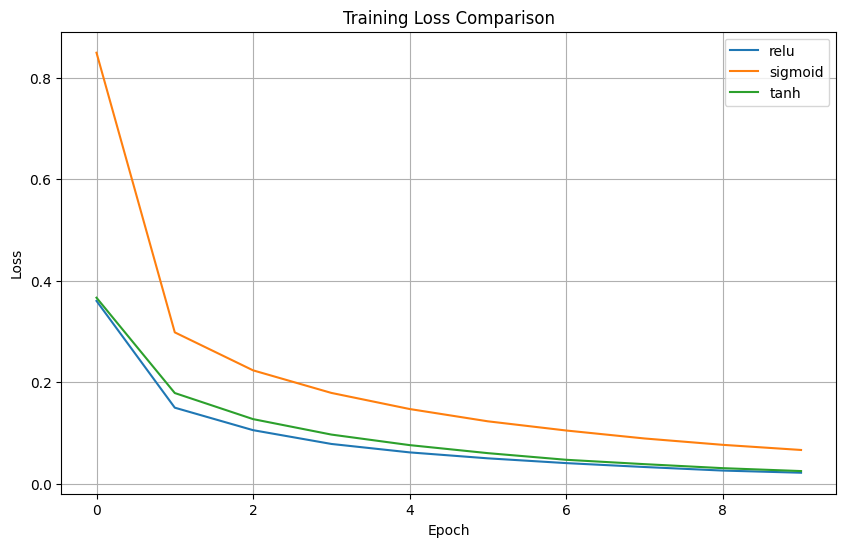

In [10]:
# ============================================================
# 9. Plot training loss
# ============================================================

plt.figure(figsize=(10, 6))

for activation in activations:
    history = results[activation]["history"]
    plt.plot(
        history.history["loss"],
        label=activation
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()



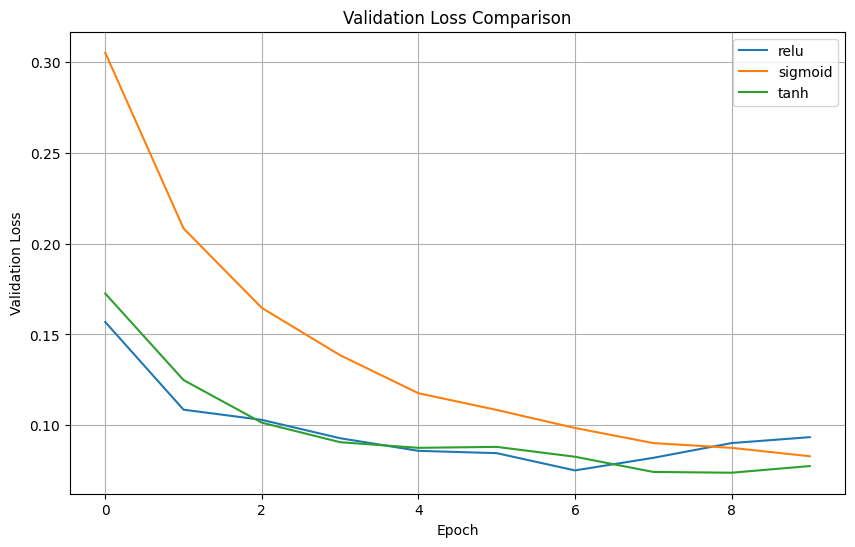

In [11]:
# ============================================================
# 10. Plot validation loss
# ============================================================

plt.figure(figsize=(10, 6))

for activation in activations:
    history = results[activation]["history"]
    plt.plot(
        history.history["val_loss"],
        label=activation
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()
plt.show()